<a href="https://colab.research.google.com/github/Poojalakshmi271/AGENTIC-AI/blob/main/Semantics_similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from absl import logging

import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns

module_url="https://tfhub.dev/google/universal-sentence-encoder/2"
model=hub.load(module_url)
print("module %s loaded" % module_url)
def embed(input):
    return model.signatures['default'](
        tf.constant(input)
    )['default'].numpy()




module https://tfhub.dev/google/universal-sentence-encoder/2 loaded


In [ ]:
word="Elephant"
sentence="I am a sentence for which I would like to get its work"
paragraph=(
    "Universal Sentence Encoder embeddings also support short paragraphs. "
    "There is no hard limit on how long the paragraph is. Roughly, the longer "
    "the more 'diluted' the embedding will be."
)

messages=[word,sentence, paragraph]

logging.set_verbosity(logging.ERROR)

message_embeddings = model.signatures['default'](tf.constant(messages))

message_embeddings = message_embeddings['default'].numpy()

for i, message_embedding in enumerate(message_embeddings):

    print("Message: {}".format(messages[i]))

    print("Embedding size: {}".format(len(message_embedding)))

    message_embedding_snippet = message_embedding[:3]

    print("Embedding: [{}, ...]\n".format(
        ", ".join(map(str, message_embedding_snippet))
    ))


Message: Elephant
Embedding size: 512
Embedding: [-0.01698726, -0.008949811, -0.007062745, ...]

Message: I am a sentence for which I would like to get its work
Embedding size: 512
Embedding: [6.251528e-05, 0.03981277, 0.004133068, ...]

Message: Universal Sentence Encoder embeddings also support short paragraphs. There is no hard limit on how long the paragraph is. Roughly, the longer the more 'diluted' the embedding will be.
Embedding size: 512
Embedding: [0.01879094, 0.045365173, -0.020010894, ...]



In [ ]:
!pip3 install seaborn tensorflow

In [ ]:
def plot_similarity(labels, features, rotation):
  corr = np.inner(features, features)
  sns.set(font_scale=1.2)
  g = sns.heatmap(
      corr,
      xticklabels=labels,
      yticklabels=labels,
      vmin=0,
      vmax=1,
      cmap="YlOrRd")
  g.set_xticklabels(labels, rotation=rotation)
  g.set_title("Semantic Textual Similarity")

def run_and_plot(messages_):
  message_embeddings_ = embed(messages_)
  plot_similarity(messages_, message_embeddings_, 90)

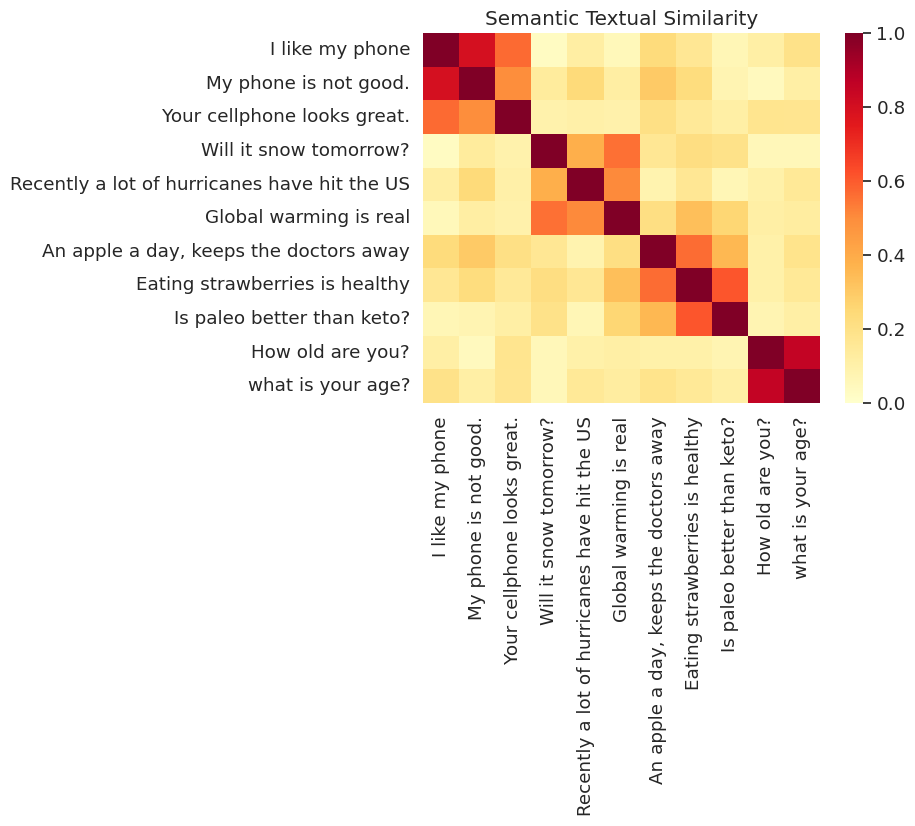

In [ ]:
messages = [
    # Smartphones
    "I like my phone",
    "My phone is not good.",
    "Your cellphone looks great.",

    # Weather
    "Will it snow tomorrow?",
    "Recently a lot of hurricanes have hit the US",
    "Global warming is real",

    # Food and health
    "An apple a day, keeps the doctors away",
    "Eating strawberries is healthy",
    "Is paleo better than keto?",

    # Asking about age
    "How old are you?",
    "what is your age?",
]

run_and_plot(messages)